# Attention Profiling for Flux 2 Klein-4B

This notebook implements **Phase 1** of the attention profiling and masking plan.

**Goals:**
1. Extract attention weight metrics from every attention layer at selected denoising timesteps
2. Visualize attention heatmaps and quadrant patterns (T→T, T→I, I→T, I→I)
3. Analyze attention entropy, sparsity, and top-k concentration across blocks and timesteps

**Architecture:**
- 5 double-stream blocks (`Flux2TransformerBlock`) with joint attention
- 20 single-stream blocks (`Flux2SingleTransformerBlock`) with parallel self-attention
- 24 attention heads, 128 dim per head


## 1. Setup & Model Loading

In [1]:
import os

if not os.path.exists('/content/diffusers_csc2210'):
    !git clone -b chenxu https://github.com/yyyyy7105/diffusers_csc2210.git

%cd /content/diffusers_csc2210

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/diffusers_csc2210
!pip install -e .


Cloning into 'diffusers_csc2210'...
remote: Enumerating objects: 75918, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 75918 (delta 2), reused 2 (delta 2), pack-reused 75914 (from 3)
Receiving objects: 100% (75918/75918), 70.83 MiB | 18.91 MiB/s, done.
Resolving deltas: 100% (57643/57643), done.
/content/diffusers_csc2210
Mounted at /content/drive
[Errno 2] No such file or directory: '/content/drive/MyDrive/diffusers_csc2210'
/content/diffusers_csc2210
Obtaining file:///content/diffusers_csc2210
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for diffusers (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.37.0.dev0-0.editable-py3-none-any.whl size=11382 sha256=f76c3fb13576916db5cb8c0beea36c226f3f64837a94066125382d44a4d

In [ ]:
import os
# Automatically restart the kernel to pick up the installed package
os._exit(00)

In [ ]:
!pip install -U bitsandbytes

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
from IPython.display import display, HTML

try:
    from diffusers import Flux2KleinPipeline, PipelineQuantizationConfig
    from diffusers.models.transformers.transformer_flux2 import (
        AttentionProfileEntry,
        AttentionProfilingStore,
    )
    print("Successfully imported diffusers components.")
except ImportError as e:
    print(f"Import failed: {e}")

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
print(f"Device: {device}, dtype: {dtype}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Successfully imported diffusers components.
Device: cuda, dtype: torch.float16


### ⚠️ Restart Required
After running the cell above, the runtime will restart. You do **not** need to run the installation cell again. Start directly from the next cell to import `diffusers`.

In [10]:
## 1.1 Model Initialization

!pip install transformers

In [2]:
# Load the model — adjust cache_dir to your local path or use HuggingFace Hub
# Option A: From local cache
# cache_dir = "/path/to/your/flux2-klein-4B/snapshot"
# pipe = Flux2KleinPipeline.from_pretrained(cache_dir, torch_dtype=dtype)

# Option B: From HuggingFace Hub with quantization
from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=dtype
)
quantization_config = PipelineQuantizationConfig(
    quant_backend="bitsandbytes_4bit",
    quant_kwargs=bnb_config.to_dict()
)

pipe = Flux2KleinPipeline.from_pretrained(
    "black-forest-labs/FLUX.2-klein-4B",
    quantization_config=quantization_config,
    torch_dtype=dtype,
)
pipe.enable_model_cpu_offload()
print(f"Model loaded. Double-stream blocks: {len(pipe.transformer.transformer_blocks)}, "
      f"Single-stream blocks: {len(pipe.transformer.single_transformer_blocks)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model loaded. Double-stream blocks: 5, Single-stream blocks: 20


## 2. Enable Attention Profiling

This swaps all attention processors to profiling variants that capture metrics
at each block and timestep, while preserving the original model output.

In [5]:
# Enable profiling mode on the transformer
# store_full_weights=False to save memory (only summary statistics are stored)
pipe.transformer.set_profiling_mode(
    enabled=True,
    store_full_weights=True,  # Capture full [B,H,S,S] attention matrices for heatmaps
    sparsity_threshold=0.01,
    topk=32,
)
print("Attention profiling enabled.")


Attention profiling enabled.


## 3. Run Inference with Profiling

We run inference with diverse prompts to capture attention patterns across different inputs.


Prompt 1/3: 'a photorealistic cat sitting on a wooden table'
I am running in: /content
I am looking for logs at: /content/log/flux2_profile


  0%|          | 0/4 [00:00<?, ?it/s]

  Captured 100 profiling entries


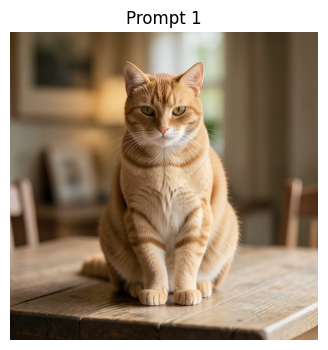


Prompt 2/3: 'a futuristic cityscape at sunset with flying cars'
I am running in: /content
I am looking for logs at: /content/log/flux2_profile


  0%|          | 0/4 [00:00<?, ?it/s]

  Captured 100 profiling entries


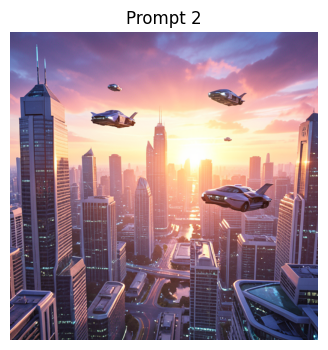


Prompt 3/3: 'abstract swirling colors in a cosmic nebula'
I am running in: /content
I am looking for logs at: /content/log/flux2_profile


  0%|          | 0/4 [00:00<?, ?it/s]

  Captured 100 profiling entries


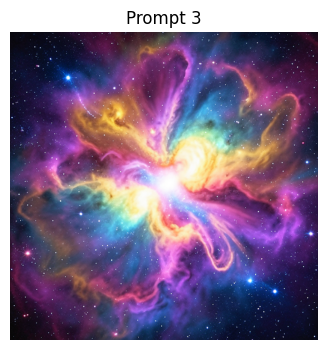


Total profiling entries: 300


In [6]:
# Define diverse prompts for profiling
prompts = [
    "a photorealistic cat sitting on a wooden table",
    "a futuristic cityscape at sunset with flying cars",
    "abstract swirling colors in a cosmic nebula",
]

# Run inference for each prompt
all_entries = []
for i, prompt in enumerate(prompts):
    pipe.transformer.clear_attention_profile_data()
    print(f"\nPrompt {i+1}/{len(prompts)}: '{prompt}'")

    image = pipe(
        prompt=prompt,
        height=512,
        width=512,
        guidance_scale=1.0,
        num_inference_steps=4,
        generator=torch.Generator(device=device).manual_seed(42),
    ).images[0]

    entries = pipe.transformer.get_attention_profile_data()
    print(f"  Captured {len(entries)} profiling entries")

    # Tag entries with prompt index
    for e in entries:
        e.prompt_index = i  # Monkey-patch for tracking
    all_entries.extend(entries)

    # Display the generated image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Prompt {i+1}")
    plt.axis("off")
    plt.show()

print(f"\nTotal profiling entries: {len(all_entries)}")


## 4. Organize Profiling Data

Group entries by block type, block index, and timestep for analysis.

In [7]:
# Organize entries into a structured dictionary
# Key: (block_type, block_index) -> list of entries across timesteps and prompts
entries_by_block = defaultdict(list)
entries_by_timestep = defaultdict(list)
unique_timesteps = sorted(set(e.timestep for e in all_entries))

for e in all_entries:
    entries_by_block[(e.block_type, e.block_index)].append(e)
    entries_by_timestep[round(e.timestep, 4)].append(e)

# Print summary
print(f"Unique timesteps: {len(unique_timesteps)}")
print(f"Unique blocks: {len(entries_by_block)}")
for key in sorted(entries_by_block.keys()):
    print(f"  {key[0]} block {key[1]}: {len(entries_by_block[key])} entries")


Unique timesteps: 4
Unique blocks: 25
  double block 0: 12 entries
  double block 1: 12 entries
  double block 2: 12 entries
  double block 3: 12 entries
  double block 4: 12 entries
  single block 0: 12 entries
  single block 1: 12 entries
  single block 2: 12 entries
  single block 3: 12 entries
  single block 4: 12 entries
  single block 5: 12 entries
  single block 6: 12 entries
  single block 7: 12 entries
  single block 8: 12 entries
  single block 9: 12 entries
  single block 10: 12 entries
  single block 11: 12 entries
  single block 12: 12 entries
  single block 13: 12 entries
  single block 14: 12 entries
  single block 15: 12 entries
  single block 16: 12 entries
  single block 17: 12 entries
  single block 18: 12 entries
  single block 19: 12 entries


## 5. Quadrant Analysis

Analyze the four attention quadrants (T→T, T→I, I→T, I→I) across block depth.

The attention matrix for a sequence of [text_tokens; image_tokens] has four regions:
```
         text_K    img_K
text_Q [ T→T      T→I   ]
img_Q  [ I→T      I→I   ]
```

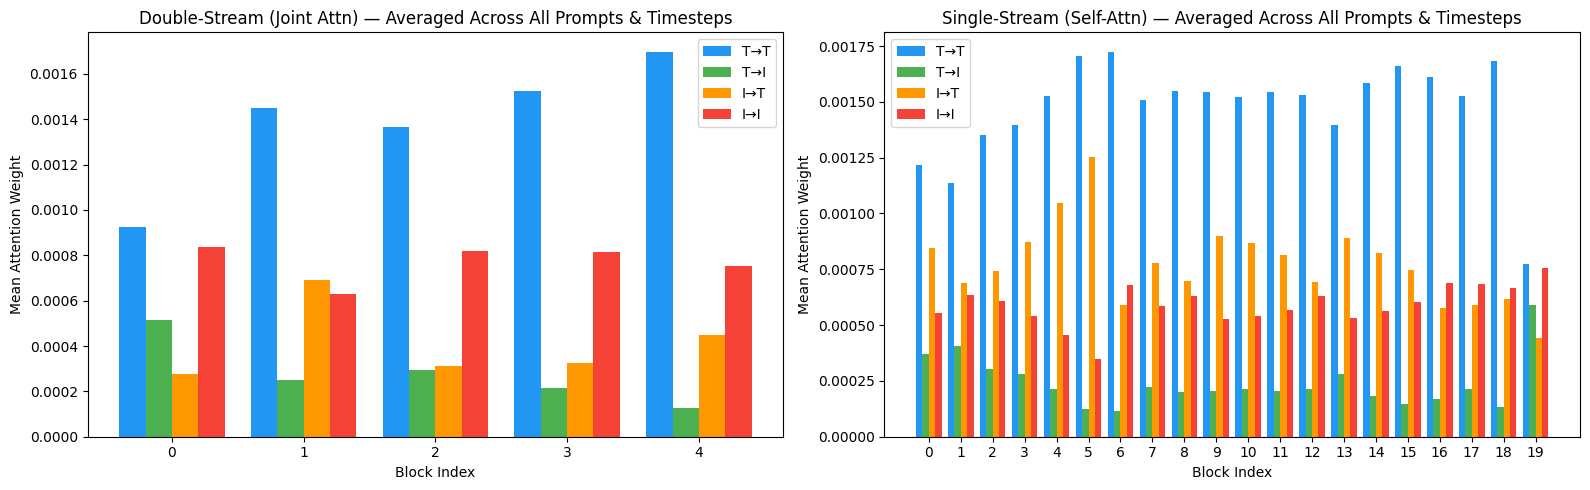

In [8]:
def plot_quadrant_analysis(entries, title_suffix=""):
    """Plot mean attention weight in each quadrant across block depth."""
    # Separate double and single stream
    double_entries = [e for e in entries if e.block_type == "double"]
    single_entries = [e for e in entries if e.block_type == "single"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, block_entries, block_label in [
        (axes[0], double_entries, "Double-Stream (Joint Attn)"),
        (axes[1], single_entries, "Single-Stream (Self-Attn)"),
    ]:
        if not block_entries:
            ax.set_title(f"{block_label} — No data")
            continue

        # Group by block index, average across timesteps and prompts
        block_indices = sorted(set(e.block_index for e in block_entries))
        quadrants = {"T→T": [], "T→I": [], "I→T": [], "I→I": []}

        for idx in block_indices:
            block_e = [e for e in block_entries if e.block_index == idx]
            quadrants["T→T"].append(np.mean([e.mean_weight_tt for e in block_e]))
            quadrants["T→I"].append(np.mean([e.mean_weight_ti for e in block_e]))
            quadrants["I→T"].append(np.mean([e.mean_weight_it for e in block_e]))
            quadrants["I→I"].append(np.mean([e.mean_weight_ii for e in block_e]))

        x = np.arange(len(block_indices))
        width = 0.2
        colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

        for i, (label, values) in enumerate(quadrants.items()):
            ax.bar(x + i * width, values, width, label=label, color=colors[i])

        ax.set_xlabel("Block Index")
        ax.set_ylabel("Mean Attention Weight")
        ax.set_title(f"{block_label}{title_suffix}")
        ax.set_xticks(x + 1.5 * width)
        ax.set_xticklabels(block_indices)
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_quadrant_analysis(all_entries, " — Averaged Across All Prompts & Timesteps")


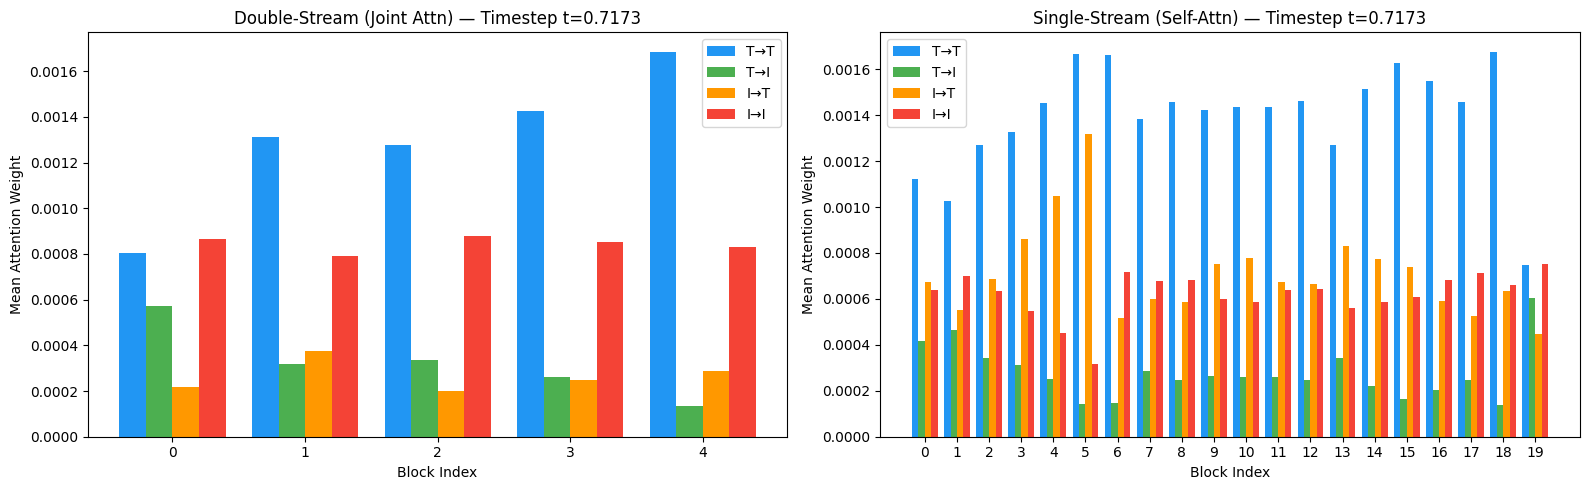

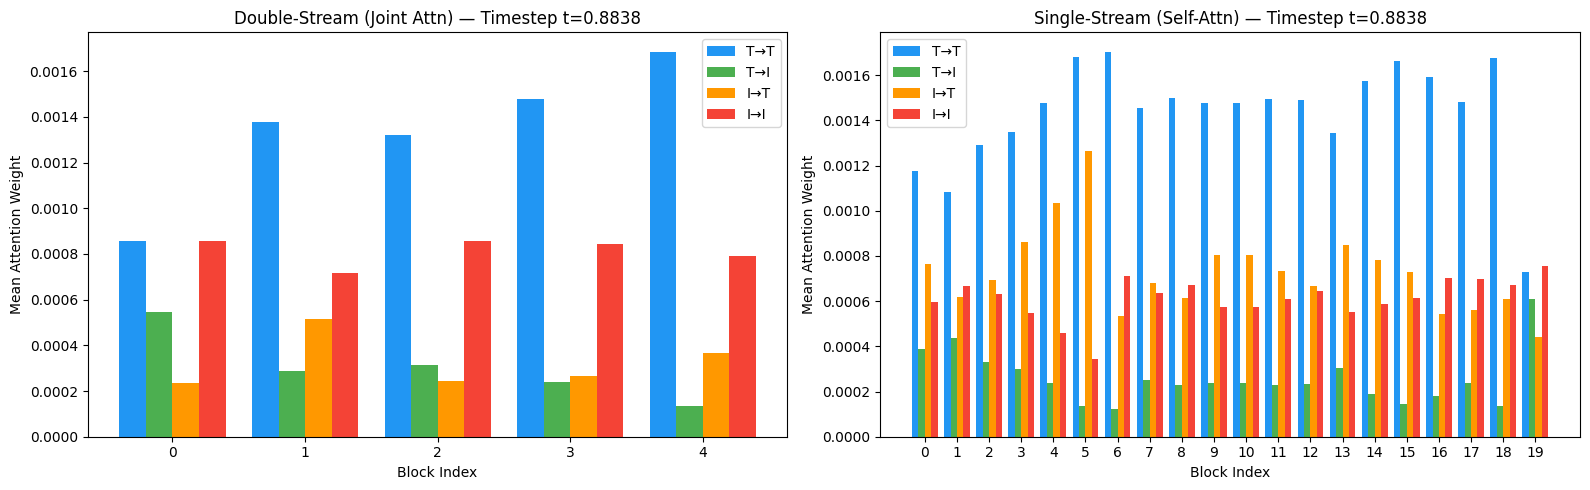

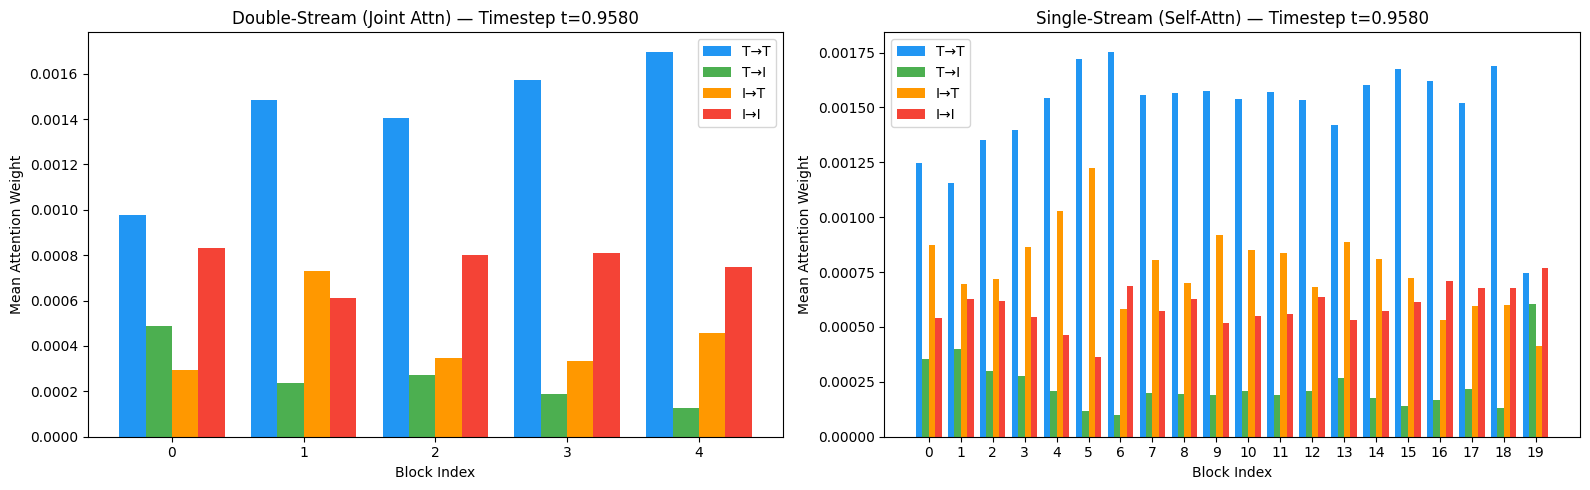

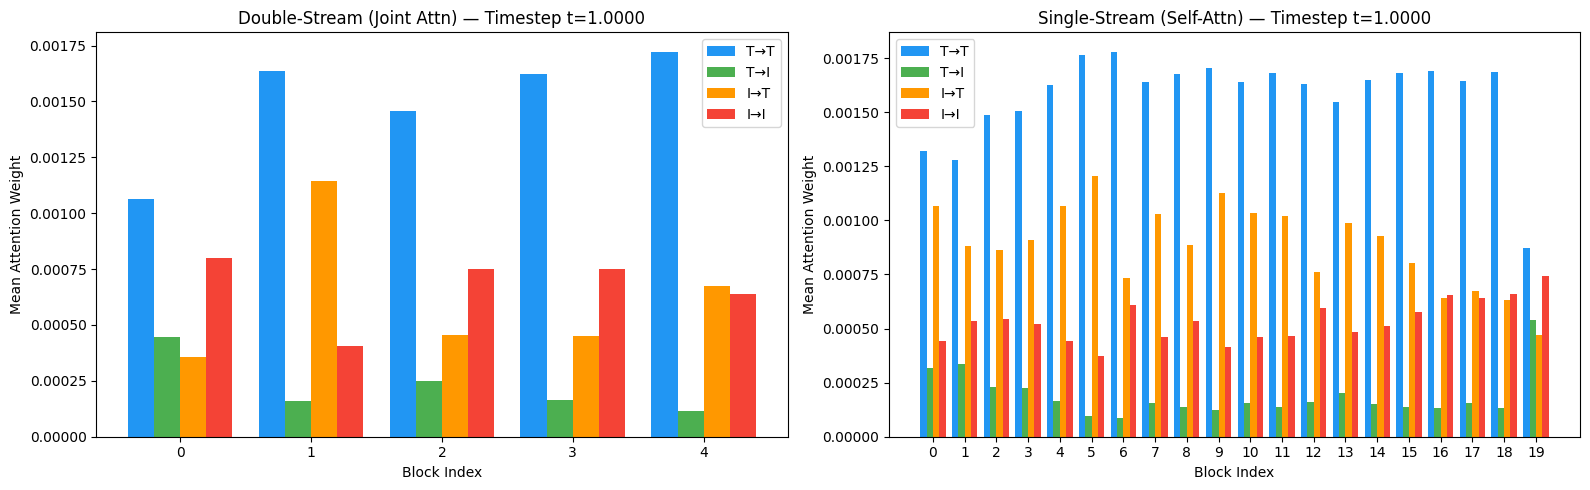

In [9]:
# Quadrant analysis per timestep
for t in unique_timesteps[::max(1, len(unique_timesteps) // 4)]:
    t_round = round(t, 4)
    t_entries = entries_by_timestep.get(t_round, [])
    if t_entries:
        plot_quadrant_analysis(t_entries, f" — Timestep t={t_round:.4f}")


## 6. Entropy & Sparsity Profiles

Plot per-block attention entropy and sparsity to identify which blocks have
exploitable sparse attention patterns.

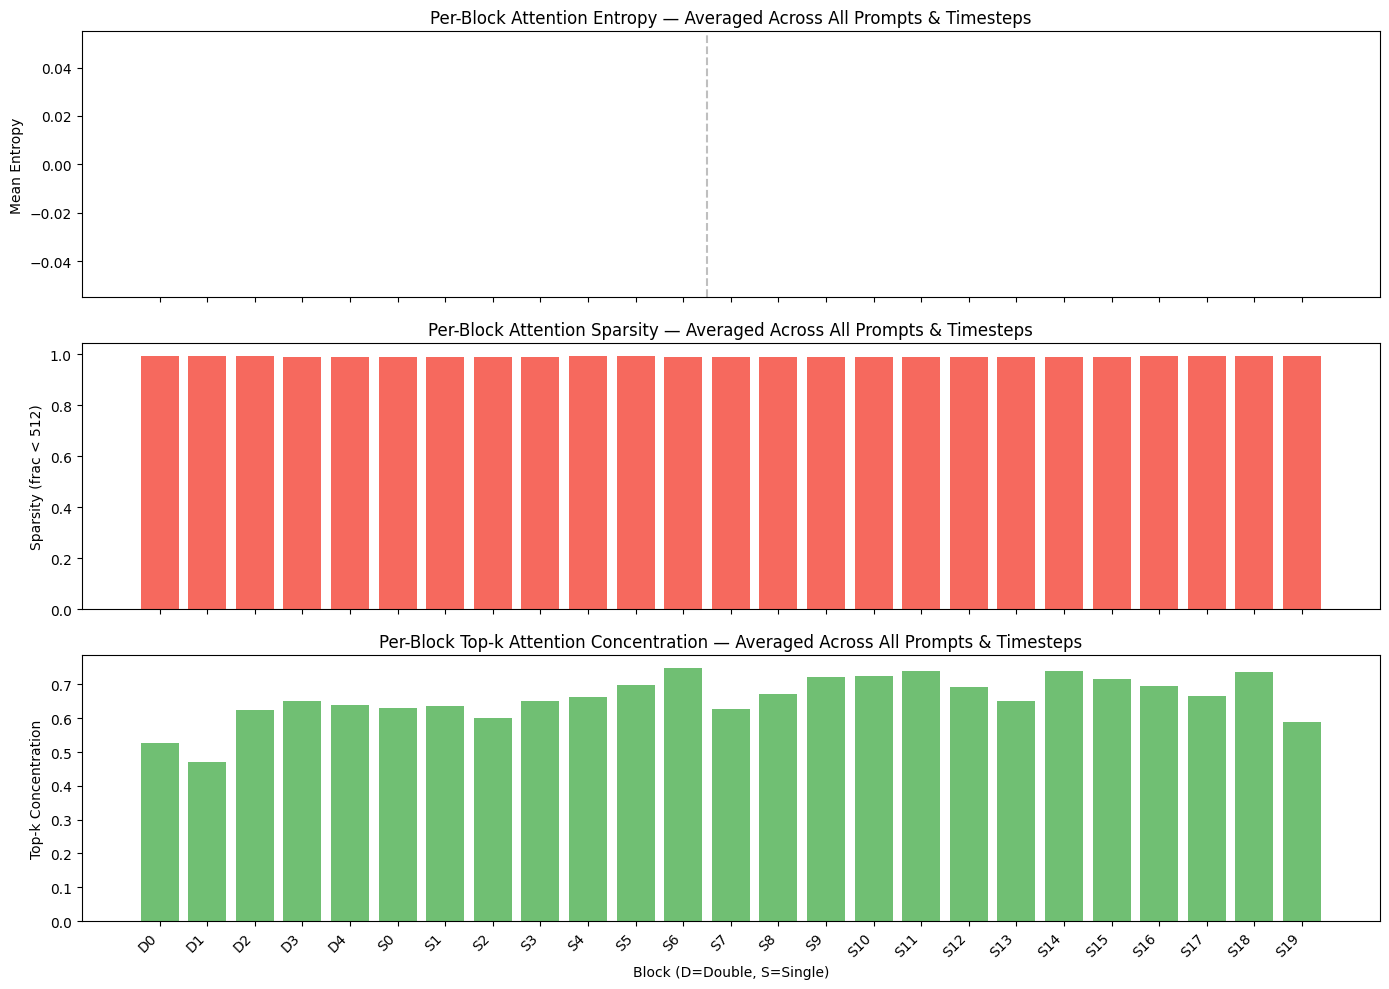

In [10]:
def plot_entropy_sparsity(entries, title_suffix=""):
    """Plot per-block entropy and sparsity."""
    double_entries = [e for e in entries if e.block_type == "double"]
    single_entries = [e for e in entries if e.block_type == "single"]

    # Combine into a single block axis: double blocks first, then single blocks
    all_blocks = []
    all_labels = []

    for e_list, prefix in [(double_entries, "D"), (single_entries, "S")]:
        block_indices = sorted(set(e.block_index for e in e_list))
        for idx in block_indices:
            block_e = [e for e in e_list if e.block_index == idx]
            mean_entropy = torch.stack([e.per_head_entropy for e in block_e]).mean().item()
            mean_sparsity = torch.stack([e.per_head_sparsity for e in block_e]).mean().item()
            mean_topk = torch.stack([e.per_head_topk_concentration for e in block_e]).mean().item()
            all_blocks.append((mean_entropy, mean_sparsity, mean_topk))
            all_labels.append(f"{prefix}{idx}")

    if not all_blocks:
        print("No data to plot.")
        return

    entropies, sparsities, topks = zip(*all_blocks)
    x = np.arange(len(all_labels))

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # Entropy plot
    ax1.bar(x, entropies, color="#2196F3", alpha=0.8)
    ax1.set_ylabel("Mean Entropy")
    ax1.set_title(f"Per-Block Attention Entropy{title_suffix}")
    ax1.axvline(x=len([e for e in double_entries if True]) // max(1, len(set(e.block_index for e in double_entries))) - 0.5 if double_entries else -1,
               color="gray", linestyle="--", alpha=0.5, label="Double→Single boundary")

    # Sparsity plot
    ax2.bar(x, sparsities, color="#F44336", alpha=0.8)
    ax2.set_ylabel(f"Sparsity (frac < {entries[0].num_text_tokens if entries else 'N/A'})")
    ax2.set_title(f"Per-Block Attention Sparsity{title_suffix}")

    # Top-k concentration plot
    ax3.bar(x, topks, color="#4CAF50", alpha=0.8)
    ax3.set_ylabel("Top-k Concentration")
    ax3.set_title(f"Per-Block Top-k Attention Concentration{title_suffix}")
    ax3.set_xticks(x)
    ax3.set_xticklabels(all_labels, rotation=45, ha="right")
    ax3.set_xlabel("Block (D=Double, S=Single)")

    plt.tight_layout()
    plt.show()

plot_entropy_sparsity(all_entries, " — Averaged Across All Prompts & Timesteps")


## 7. Per-Head Analysis

Examine whether individual attention heads specialize in different patterns.

=== Double-Stream Blocks ===


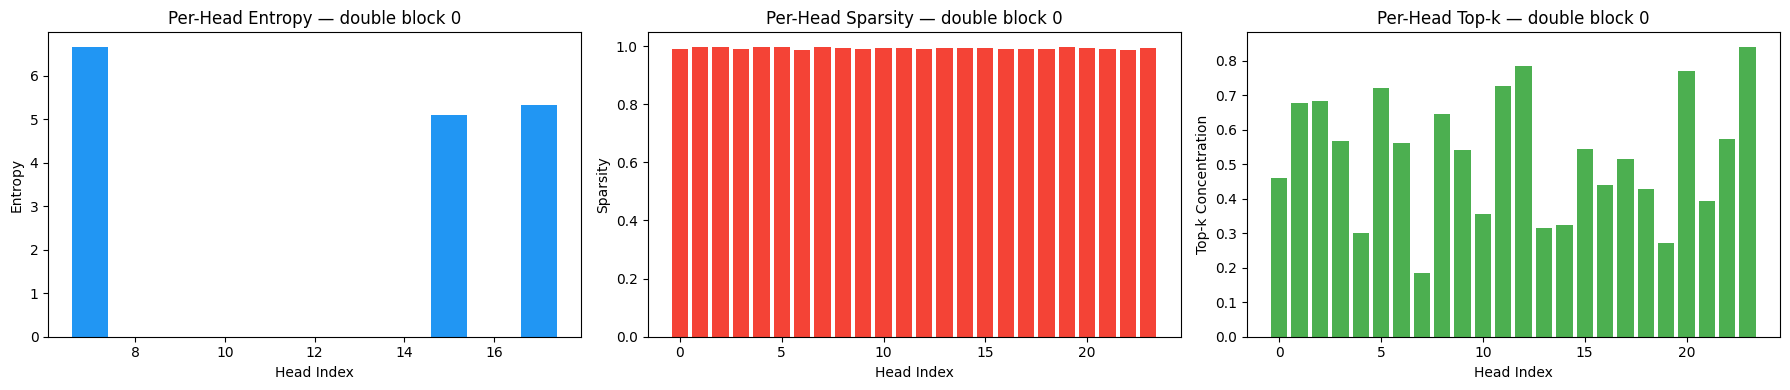

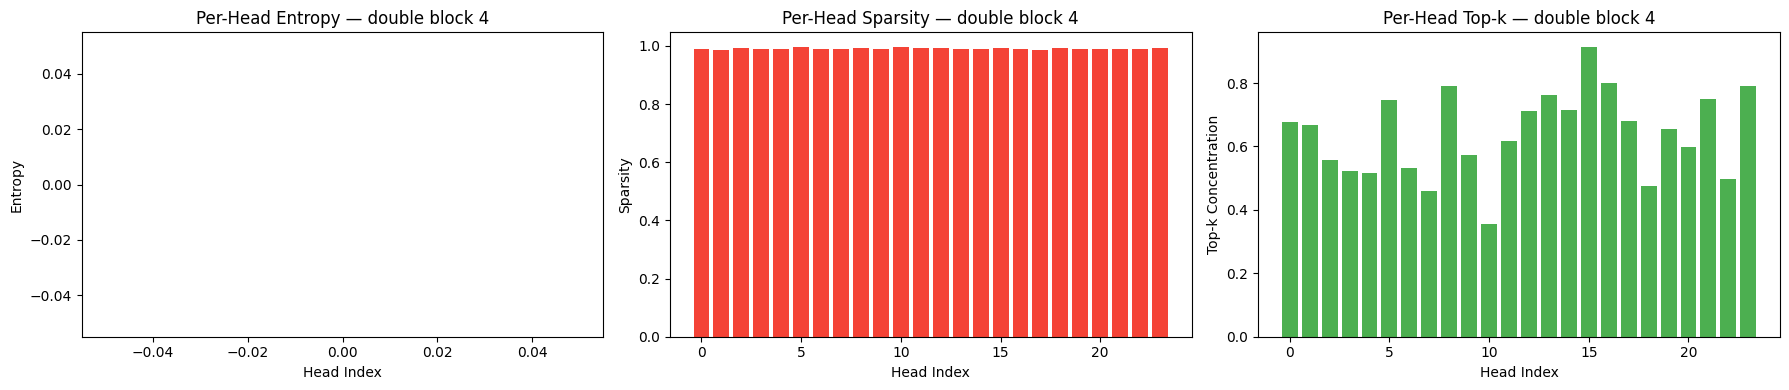


=== Single-Stream Blocks ===


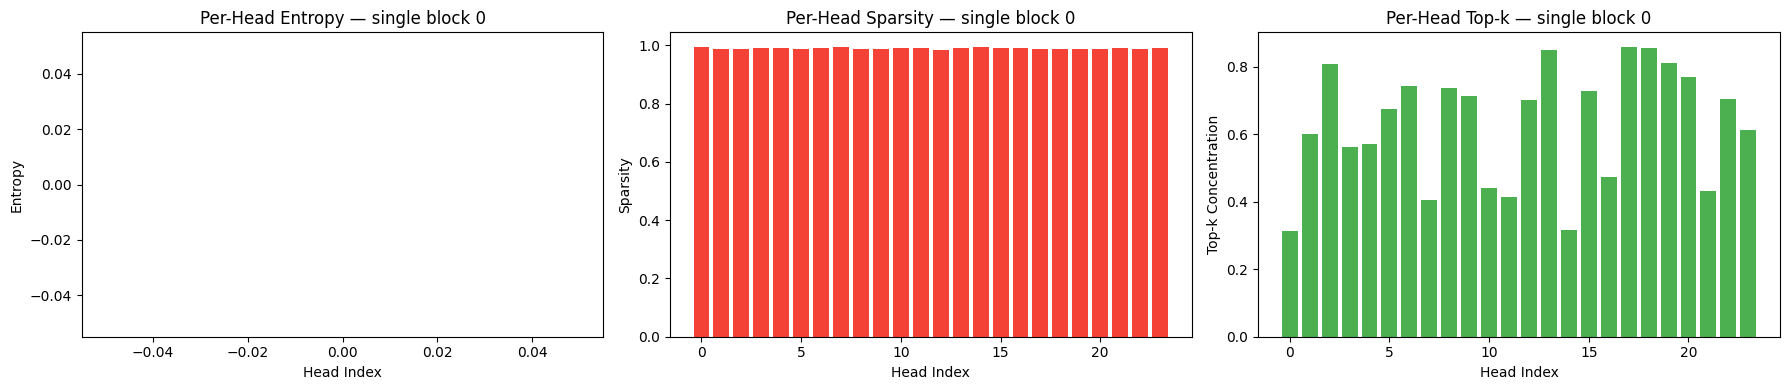

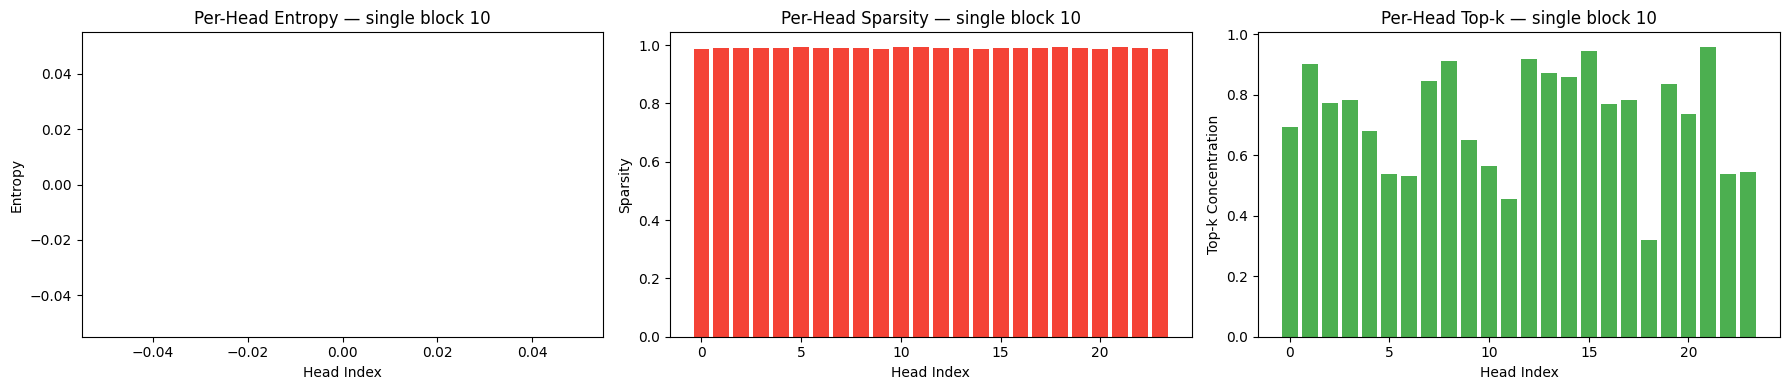

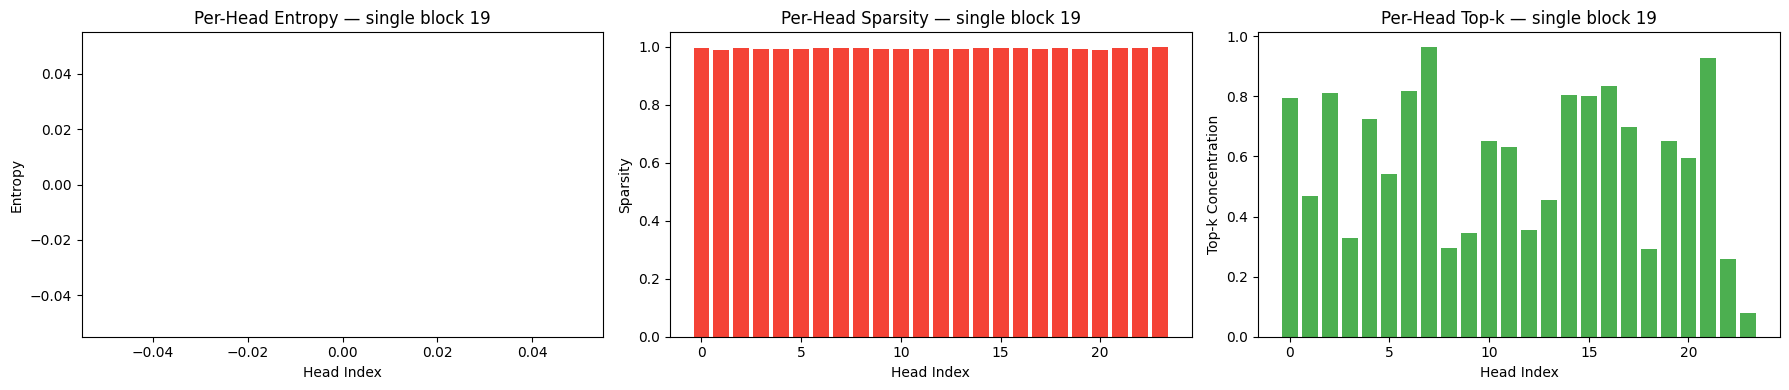

In [11]:
def plot_per_head_analysis(entries, block_type="double", block_index=0):
    """Plot per-head entropy and sparsity for a specific block."""
    block_entries = [e for e in entries if e.block_type == block_type and e.block_index == block_index]
    if not block_entries:
        print(f"No data for {block_type} block {block_index}")
        return

    # Average across timesteps and prompts
    entropies = torch.stack([e.per_head_entropy for e in block_entries]).mean(dim=0)  # [H]
    sparsities = torch.stack([e.per_head_sparsity for e in block_entries]).mean(dim=0)  # [H]
    topks = torch.stack([e.per_head_topk_concentration for e in block_entries]).mean(dim=0)  # [H]

    num_heads = entropies.shape[0]
    x = np.arange(num_heads)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

    ax1.bar(x, entropies.numpy(), color="#2196F3")
    ax1.set_xlabel("Head Index")
    ax1.set_ylabel("Entropy")
    ax1.set_title(f"Per-Head Entropy — {block_type} block {block_index}")

    ax2.bar(x, sparsities.numpy(), color="#F44336")
    ax2.set_xlabel("Head Index")
    ax2.set_ylabel("Sparsity")
    ax2.set_title(f"Per-Head Sparsity — {block_type} block {block_index}")

    ax3.bar(x, topks.numpy(), color="#4CAF50")
    ax3.set_xlabel("Head Index")
    ax3.set_ylabel("Top-k Concentration")
    ax3.set_title(f"Per-Head Top-k — {block_type} block {block_index}")

    plt.tight_layout()
    plt.show()

# Plot per-head analysis for selected blocks
# Double-stream: first and last
num_double = len(pipe.transformer.transformer_blocks)
num_single = len(pipe.transformer.single_transformer_blocks)

print("=== Double-Stream Blocks ===")
for idx in [0, num_double - 1]:
    plot_per_head_analysis(all_entries, "double", idx)

print("\n=== Single-Stream Blocks ===")
for idx in [0, num_single // 2, num_single - 1]:
    plot_per_head_analysis(all_entries, "single", idx)


## 8. Temporal Evolution

How do attention patterns change across denoising timesteps?

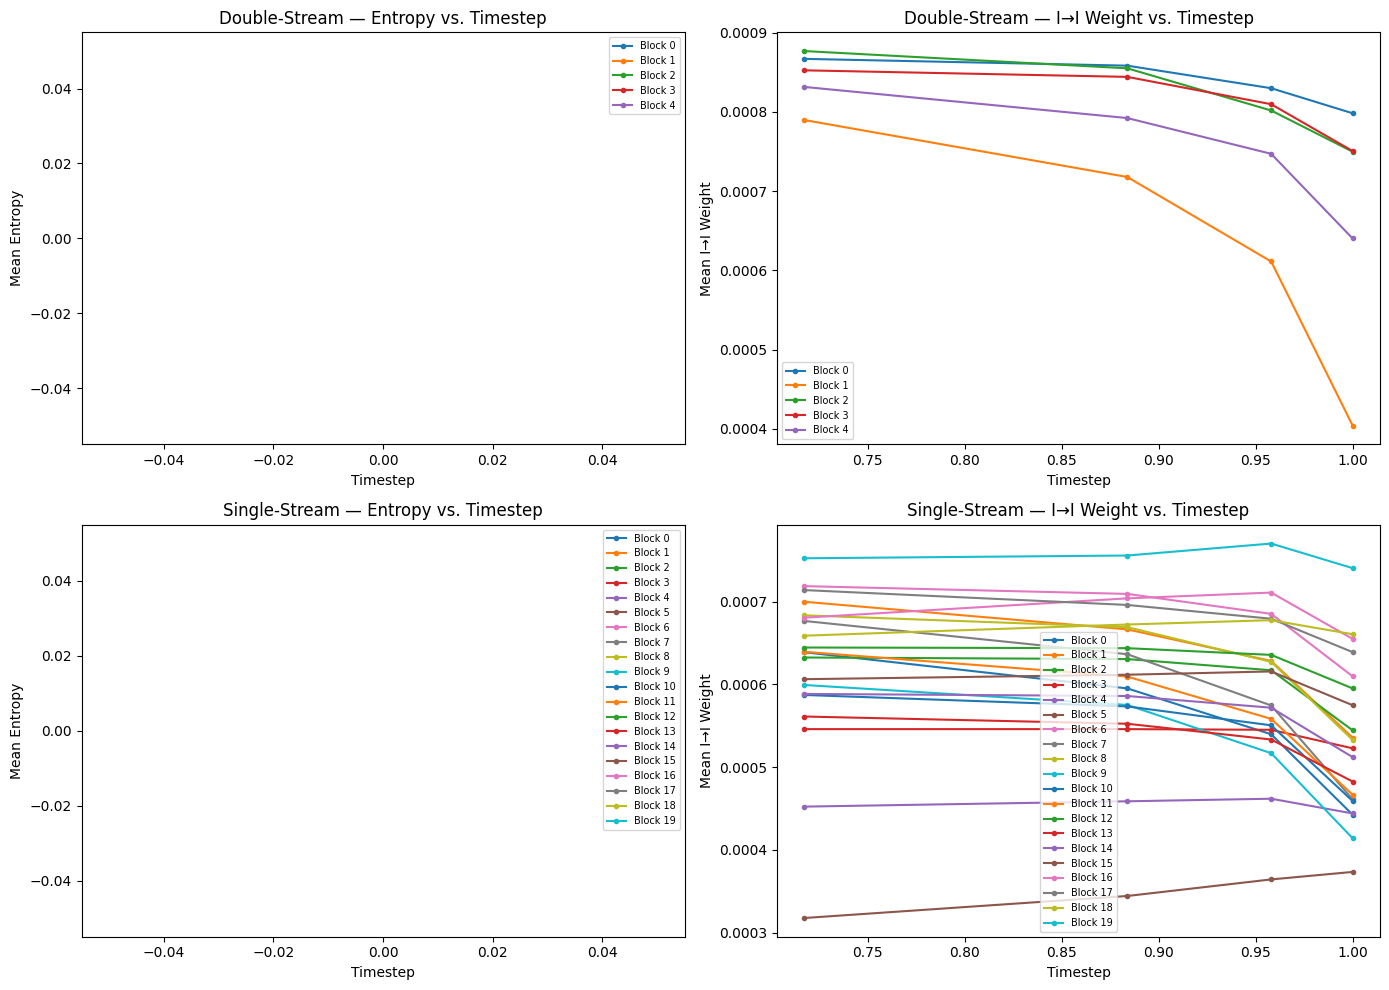

In [12]:
def plot_temporal_evolution(entries):
    """Plot how entropy and quadrant ratios change across timesteps."""
    timesteps = sorted(set(e.timestep for e in entries))
    if len(timesteps) < 2:
        print("Need at least 2 timesteps for temporal evolution plot.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax_row, block_type, label in [
        (axes[0], "double", "Double-Stream"),
        (axes[1], "single", "Single-Stream"),
    ]:
        block_entries = [e for e in entries if e.block_type == block_type]
        if not block_entries:
            continue

        block_indices = sorted(set(e.block_index for e in block_entries))

        # Entropy evolution
        ax = ax_row[0]
        for idx in block_indices:
            t_vals = []
            e_vals = []
            for t in timesteps:
                te = [e for e in block_entries if e.block_index == idx and abs(e.timestep - t) < 1e-6]
                if te:
                    t_vals.append(t)
                    e_vals.append(np.mean([e.per_head_entropy.mean().item() for e in te]))
            if t_vals:
                ax.plot(t_vals, e_vals, marker="o", label=f"Block {idx}", markersize=3)
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Mean Entropy")
        ax.set_title(f"{label} — Entropy vs. Timestep")
        ax.legend(fontsize=7)

        # I→I quadrant evolution (most relevant for masking)
        ax = ax_row[1]
        for idx in block_indices:
            t_vals = []
            ii_vals = []
            for t in timesteps:
                te = [e for e in block_entries if e.block_index == idx and abs(e.timestep - t) < 1e-6]
                if te:
                    t_vals.append(t)
                    ii_vals.append(np.mean([e.mean_weight_ii for e in te]))
            if t_vals:
                ax.plot(t_vals, ii_vals, marker="o", label=f"Block {idx}", markersize=3)
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Mean I→I Weight")
        ax.set_title(f"{label} — I→I Weight vs. Timestep")
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

plot_temporal_evolution(all_entries)


## 9. Summary Statistics Table

Generate a comprehensive table of profiling metrics for all blocks.

In [13]:
def print_summary_table(entries):
    """Print a summary table of profiling metrics."""
    print(f"{'Type':<8} {'Block':<6} {'#Entries':<9} {'T→T':>8} {'T→I':>8} {'I→T':>8} {'I→I':>8} "
          f"{'Entropy':>8} {'Sparsity':>9} {'Top-k':>8}")
    print("-" * 95)

    for block_type in ["double", "single"]:
        block_entries = [e for e in entries if e.block_type == block_type]
        block_indices = sorted(set(e.block_index for e in block_entries))

        for idx in block_indices:
            be = [e for e in block_entries if e.block_index == idx]
            n = len(be)
            tt = np.mean([e.mean_weight_tt for e in be])
            ti = np.mean([e.mean_weight_ti for e in be])
            it = np.mean([e.mean_weight_it for e in be])
            ii = np.mean([e.mean_weight_ii for e in be])
            ent = np.mean([e.per_head_entropy.mean().item() for e in be])
            sp = np.mean([e.per_head_sparsity.mean().item() for e in be])
            tk = np.mean([e.per_head_topk_concentration.mean().item() for e in be])
            print(f"{block_type:<8} {idx:<6} {n:<9} {tt:>8.5f} {ti:>8.5f} {it:>8.5f} {ii:>8.5f} "
                  f"{ent:>8.3f} {sp:>9.4f} {tk:>8.4f}")

        if block_type == "double" and block_entries:
            print("-" * 95)

print_summary_table(all_entries)


Type     Block  #Entries       T→T      T→I      I→T      I→I  Entropy  Sparsity    Top-k
-----------------------------------------------------------------------------------------------
double   0      12         0.00093  0.00051  0.00028  0.00084      nan    0.9927   0.5262
double   1      12         0.00145  0.00025  0.00069  0.00063      nan    0.9923   0.4697
double   2      12         0.00137  0.00029  0.00031  0.00082      nan    0.9923   0.6240
double   3      12         0.00153  0.00021  0.00032  0.00081      nan    0.9909   0.6518
double   4      12         0.00170  0.00013  0.00045  0.00075      nan    0.9904   0.6403
-----------------------------------------------------------------------------------------------
single   0      12         0.00122  0.00037  0.00084  0.00055      nan    0.9902   0.6292
single   1      12         0.00114  0.00041  0.00069  0.00063      nan    0.9895   0.6353
single   2      12         0.00135  0.00030  0.00074  0.00061      nan    0.9904   0.601

## 10. Attention Heatmaps

Visualize the raw attention weight matrices for selected blocks and heads.
This requires `store_full_weights=True` during profiling.
The heatmap shows the full [S, S] attention matrix with text and image regions labeled.

In [ ]:
def plot_attention_heatmap(entries, block_type="double", block_index=0, head_idx=0, prompt_idx=0, timestep_idx=0):
    """Plot the full attention heatmap for a specific block, head, prompt, and timestep.
    
    Requires store_full_weights=True during profiling.
    """
    # Filter entries
    filtered = [e for e in entries
               if e.block_type == block_type
               and e.block_index == block_index
               and hasattr(e, "prompt_index") and e.prompt_index == prompt_idx]
    
    # Sort by timestep and pick the requested index
    filtered = sorted(filtered, key=lambda e: e.timestep)
    if timestep_idx >= len(filtered):
        print(f"Only {len(filtered)} timesteps available for {block_type} block {block_index}, prompt {prompt_idx}")
        return
    entry = filtered[timestep_idx]
    
    if entry.full_attention_weights is None:
        print("No full attention weights stored. Set store_full_weights=True and re-run profiling.")
        return
    
    # full_attention_weights: [B, H, S, S] — take batch 0
    attn = entry.full_attention_weights[0].float()  # [H, S, S]
    if head_idx >= attn.shape[0]:
        print(f"Only {attn.shape[0]} heads available.")
        return
    
    attn_map = attn[head_idx].numpy()  # [S, S]
    t = entry.num_text_tokens
    S = attn_map.shape[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Full attention heatmap
    ax = axes[0]
    im = ax.imshow(attn_map, aspect="auto", cmap="viridis")
    ax.set_title(f"{block_type} block {block_index}, head {head_idx}\n"
                 f"t={entry.timestep:.4f}, prompt {prompt_idx}")
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
    # Draw quadrant boundaries
    if t > 0 and t < S:
        ax.axhline(y=t - 0.5, color="red", linewidth=1.5, linestyle="--", alpha=0.7)
        ax.axvline(x=t - 0.5, color="red", linewidth=1.5, linestyle="--", alpha=0.7)
        ax.text(t / 2, -2, "Text K", ha="center", fontsize=8, color="red")
        ax.text(t + (S - t) / 2, -2, "Image K", ha="center", fontsize=8, color="red")
        ax.text(-2, t / 2, "Text Q", ha="right", va="center", fontsize=8, color="red", rotation=90)
        ax.text(-2, t + (S - t) / 2, "Image Q", ha="right", va="center", fontsize=8, color="red", rotation=90)
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # I→I quadrant zoomed in
    ax = axes[1]
    if t < S:
        ii_attn = attn_map[t:, t:]
        im2 = ax.imshow(ii_attn, aspect="auto", cmap="viridis")
        ax.set_title(f"I→I Quadrant (Image Self-Attention)\n"
                     f"{block_type} block {block_index}, head {head_idx}")
        ax.set_xlabel("Image Key position")
        ax.set_ylabel("Image Query position")
        plt.colorbar(im2, ax=ax, shrink=0.8)
    else:
        ax.set_title("No image tokens")
    
    plt.tight_layout()
    plt.show()

# Plot heatmaps for first prompt, first timestep, various blocks and heads
print("=== Attention Heatmaps ===")
for bt, bi in [("double", 0), ("double", 4), ("single", 0), ("single", 10), ("single", 19)]:
    for head in [0, 5]:
        plot_attention_heatmap(all_entries, block_type=bt, block_index=bi, head_idx=head,
                              prompt_idx=0, timestep_idx=0)


## 11. Attention Locality Analysis

Analyze whether image self-attention (I→I) exhibits **spatial locality** — i.e., whether
each image query token attends primarily to nearby key tokens on the 2D spatial grid.

The **locality profile** plots mean I→I attention weight vs. Manhattan distance on the image grid.
A steeply decaying curve indicates strong locality (attention focused on nearby tokens),
while a flat curve indicates global attention patterns.

In [ ]:
def plot_locality_profiles(entries, title_suffix=""):
    """Plot I→I attention locality profiles: mean attention weight vs spatial distance."""
    # Collect entries with locality data
    valid = [e for e in entries if e.ii_locality_profile is not None]
    if not valid:
        print("No locality profile data. Ensure profiling captured ii_locality_profile.")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    for ax, block_type, label in [
        (axes[0], "double", "Double-Stream"),
        (axes[1], "single", "Single-Stream"),
    ]:
        block_entries = [e for e in valid if e.block_type == block_type]
        if not block_entries:
            ax.set_title(f"{label} — No data")
            continue
        
        block_indices = sorted(set(e.block_index for e in block_entries))
        
        for idx in block_indices:
            be = [e for e in block_entries if e.block_index == idx]
            # Average locality profiles across prompts and timesteps
            # Profiles may differ in length; pad to max length
            max_len = max(e.ii_locality_profile.shape[0] for e in be)
            profiles = []
            for e in be:
                p = e.ii_locality_profile
                if p.shape[0] < max_len:
                    p = torch.nn.functional.pad(p, (0, max_len - p.shape[0]), value=0)
                profiles.append(p)
            mean_profile = torch.stack(profiles).mean(dim=0).numpy()
            ax.plot(range(len(mean_profile)), mean_profile, marker=".", markersize=3, label=f"Block {idx}")
        
        ax.set_xlabel("Manhattan Distance (pixels)")
        ax.set_ylabel("Mean I→I Attention Weight")
        ax.set_title(f"{label} — I→I Locality Profile{title_suffix}")
        ax.legend(fontsize=7, ncol=2)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_locality_profiles(all_entries, " — Averaged Across Prompts & Timesteps")


In [ ]:
# Locality profiles per timestep
for t in unique_timesteps[::max(1, len(unique_timesteps) // 4)]:
    t_round = round(t, 4)
    t_entries = entries_by_timestep.get(t_round, [])
    if t_entries:
        plot_locality_profiles(t_entries, f" — Timestep t={t_round:.4f}")


In [ ]:
def print_locality_summary(entries):
    """Print a summary of locality: ratio of attention at distance 0-2 vs distance 5+."""
    valid = [e for e in entries if e.ii_locality_profile is not None]
    if not valid:
        print("No locality data.")
        return
    
    print(f"{"Type":<8} {"Block":<6} {"d=0":>10} {"d=1":>10} {"d=2":>10} {"d≥5":>10} {"Near/Far":>10}")
    print("-" * 60)
    
    for block_type in ["double", "single"]:
        be_all = [e for e in valid if e.block_type == block_type]
        block_indices = sorted(set(e.block_index for e in be_all))
        for idx in block_indices:
            be = [e for e in be_all if e.block_index == idx]
            max_len = max(e.ii_locality_profile.shape[0] for e in be)
            profiles = []
            for e in be:
                p = e.ii_locality_profile
                if p.shape[0] < max_len:
                    p = torch.nn.functional.pad(p, (0, max_len - p.shape[0]), value=0)
                profiles.append(p)
            mean_p = torch.stack(profiles).mean(dim=0)
            
            d0 = mean_p[0].item() if len(mean_p) > 0 else 0
            d1 = mean_p[1].item() if len(mean_p) > 1 else 0
            d2 = mean_p[2].item() if len(mean_p) > 2 else 0
            far = mean_p[5:].mean().item() if len(mean_p) > 5 else 0
            ratio = (d0 + d1 + d2) / (3 * far) if far > 1e-10 else float("inf")
            print(f"{block_type:<8} {idx:<6} {d0:>10.6f} {d1:>10.6f} {d2:>10.6f} {far:>10.6f} {ratio:>10.2f}x")
        
        if block_type == "double":
            print("-" * 60)

print("\nLocality Summary: Near (d=0,1,2) vs Far (d≥5) attention ratio")
print("Higher ratio = stronger locality (attention concentrated on nearby tokens)\n")
print_locality_summary(all_entries)


## 12. Save Profiling Data

Save the profiling data for offline analysis and Phase 2 masking experiments.

In [14]:
import pickle
import os

# Save profiling entries
output_dir = "2210/profiling_results"
os.makedirs(output_dir, exist_ok=True)

# Save as pickle for full fidelity
save_path = os.path.join(output_dir, "attention_profile_entries.pkl")
with open(save_path, "wb") as f:
    pickle.dump(all_entries, f)
print(f"Saved {len(all_entries)} entries to {save_path}")

# Also save a CSV summary for quick inspection
import csv
csv_path = os.path.join(output_dir, "attention_profile_summary.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "block_type", "block_index", "timestep", "num_text_tokens", "num_image_tokens",
        "mean_weight_tt", "mean_weight_ti", "mean_weight_it", "mean_weight_ii",
        "mean_entropy", "mean_sparsity", "mean_topk_concentration",
        "locality_d0", "locality_d1", "locality_d2",
    ])
    for e in all_entries:
        lp = e.ii_locality_profile
        d0 = lp[0].item() if lp is not None and len(lp) > 0 else ""
        d1 = lp[1].item() if lp is not None and len(lp) > 1 else ""
        d2 = lp[2].item() if lp is not None and len(lp) > 2 else ""
        writer.writerow([
            e.block_type, e.block_index, e.timestep, e.num_text_tokens, e.num_image_tokens,
            e.mean_weight_tt, e.mean_weight_ti, e.mean_weight_it, e.mean_weight_ii,
            e.per_head_entropy.mean().item(), e.per_head_sparsity.mean().item(),
            e.per_head_topk_concentration.mean().item(),
            d0, d1, d2,
        ])
print(f"Saved CSV summary to {csv_path}")

Saved 300 entries to 2210/profiling_results/attention_profile_entries.pkl
Saved CSV summary to 2210/profiling_results/attention_profile_summary.csv


## 13. Disable Profiling

Restore standard attention processors for normal inference.

In [ ]:
# Disable profiling and restore standard processors
pipe.transformer.set_profiling_mode(enabled=False)
print("Attention profiling disabled. Standard processors restored.")


## 14. Next Steps (Phase 2)

Based on the profiling results above, identify:
1. Which quadrants show low attention energy → candidates for quadrant masking (Strategy A)
2. Which blocks show high sparsity → candidates for depth-selective masking (Strategy D)
3. Whether I→I attention shows spatial locality → candidate for local window masking (Strategy B)
4. Whether attention patterns vary significantly across timesteps → need for adaptive masking

See `2210/attention_profiling_and_masking_plan.md` for the full experiment plan.